# 00. Data Structure and Exploratory Analysis

This notebook is the foundation for every later study in the project. It documents what the panel looks like before any modeling, runs the diagnostics that constrain model choice, and adds three new pieces of analysis that were missing from the midway report:

1. **Multi-horizon coupling** — the four horizons at the same `(code, sub_code, sub_category, ts_index)` are not independent series.
2. **Cumulation hypothesis** — the target at horizon `k` is approximately the rolling sum of the H1 process over `k` steps.
3. **Per-horizon weight concentration** — the maximum weight in the panel lives at H3, not H1, which means H3 disproportionately drives the weighted skill score.

The diagnostic sections (stationarity, ACF, STL, etc.) are deferred to the appendix because they are unchanged from the midway and add length without changing modeling decisions.


## 0. Setup

Imports, paths, and a single seed. We deliberately load only the columns we need at any point: the full panel with all 86 features is ~3.5 GB in pandas, so feature-level work runs on a stratified sample.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from cf import io, viz, splits

viz.apply_report_style()

SEED = 0
np.random.seed(SEED)

KEY_COLS = ['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight']
FIG_DIR = io.FIGURES_DIR

print(f'Project root : {io.PROJECT_ROOT}')
print(f'Figures dir  : {FIG_DIR}')

Project root : /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/claude_forecasting
Figures dir  : /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/claude_forecasting/report/figures


In [2]:
train_keys = io.load_train_pandas(columns=KEY_COLS)
test_keys = io.load_test_pandas(columns=[c for c in KEY_COLS if c not in ('y_target', 'weight')])

print(f'train rows: {len(train_keys):,}')
print(f'test  rows: {len(test_keys):,}')
print(f'train columns sample: {KEY_COLS}')

train rows: 5,337,414
test  rows: 1,447,107
train columns sample: ['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight']


## 1. Schema and panel structure

A row in this dataset is identified by `(code, sub_code, sub_category, horizon, ts_index)`. The full panel has 23 codes, 180 sub-codes, 5 sub-categories, 4 horizons, and runs over `ts_index` 1 to 3601 in train, 3602 to 4376 in test.


In [3]:
overview = {
    'train_rows': len(train_keys),
    'test_rows': len(test_keys),
    'codes': train_keys['code'].nunique(),
    'sub_codes': train_keys['sub_code'].nunique(),
    'sub_categories': train_keys['sub_category'].nunique(),
    'horizons': sorted(train_keys['horizon'].unique().tolist()),
    'ts_index_train_range': (int(train_keys['ts_index'].min()), int(train_keys['ts_index'].max())),
    'ts_index_test_range': (int(test_keys['ts_index'].min()), int(test_keys['ts_index'].max())),
    'distinct_series': train_keys.groupby(['code', 'sub_code', 'sub_category', 'horizon']).ngroups,
}
pd.Series(overview).to_frame('value')

,value
train_rows,5337414
test_rows,1447107
codes,23
sub_codes,180
sub_categories,5
horizons,"[1, 3, 10, 25]"
ts_index_train_range,"(1, 3601)"
ts_index_test_range,"(3602, 4376)"
distinct_series,36923


**Reading.** The panel is large. Train ends at `ts_index = 3601`, test begins at `3602`, so test is a strict temporal suffix and validation must respect chronology. The "distinct series" count counts a series as the cross-product of `(code, sub_code, sub_category, horizon)`, which is the natural unit for forecasting.


## 2. Train vs test comparability

If train and test live on different schemas or different supports, naive modeling breaks.


In [4]:
train_cols = set(io.load_train_pandas(columns=None).columns) if False else None  # avoid full load

# Cheaper: read schemas only
import pyarrow.parquet as pq
train_schema = pq.read_schema(io.RAW_DIR / 'train.parquet')
test_schema = pq.read_schema(io.RAW_DIR / 'test.parquet')
train_cols = set(train_schema.names)
test_cols = set(test_schema.names)

print('Columns in train only:', sorted(train_cols - test_cols))
print('Columns in test only :', sorted(test_cols - train_cols))

cat_alignment = pd.DataFrame({
    'train_unique': [train_keys[c].nunique() for c in ['code', 'sub_code', 'sub_category', 'horizon']],
    'test_unique':  [test_keys[c].nunique() for c in ['code', 'sub_code', 'sub_category', 'horizon']],
}, index=['code', 'sub_code', 'sub_category', 'horizon'])

cat_alignment['test_subset_of_train'] = [
    set(test_keys[c].unique()).issubset(set(train_keys[c].unique()))
    for c in cat_alignment.index
]
cat_alignment

Columns in train only: ['weight', 'y_target']
Columns in test only : []


,train_unique,test_unique,test_subset_of_train
code,23,23,True
sub_code,180,47,False
sub_category,5,5,True
horizon,4,4,True


**Reading.** The only train-only columns are `y_target` and `weight`, which is correct (test carries no labels or metric weights). Every category level seen in test already exists in train — so there is no cold-start schema problem. The `sub_code` cardinality drops from 180 in train to 47 in test, which is a coverage shift rather than a schema mismatch.


## 3. Missing values

Imputation strategy follows from how much is missing and where.


In [5]:
# Compute missingness on a 500k-row sample to keep RAM in check
sample_for_missing = pd.read_parquet(io.RAW_DIR / 'train.parquet').sample(500_000, random_state=SEED)
missing = sample_for_missing.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f'Columns with any missing values: {len(missing)}')
print(missing.head(10).to_string())

Columns with any missing values: 48
feature_at    0.124270
feature_by    0.109910
feature_ay    0.086044
feature_cd    0.075604
feature_ce    0.051600
feature_cf    0.044220
feature_al    0.042052
feature_aw    0.038580
feature_bz    0.028616
feature_bi    0.027998


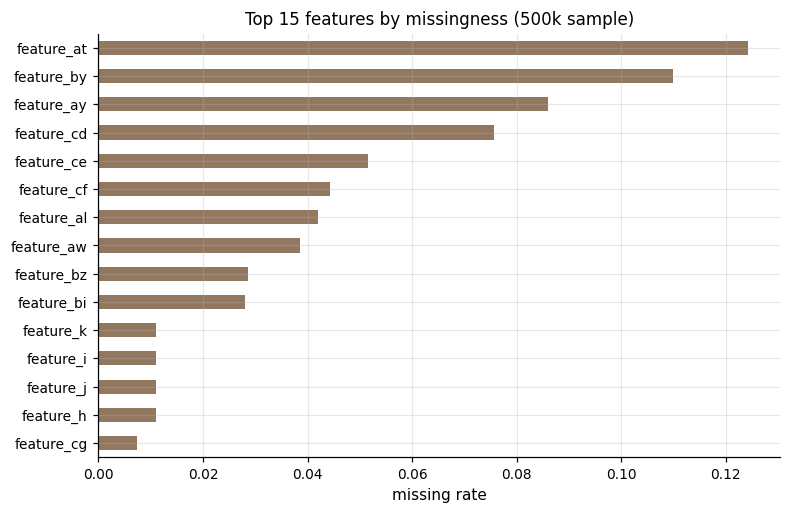

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
missing.head(15).sort_values().plot.barh(ax=ax, color='#937860')
ax.set_xlabel('missing rate')
ax.set_title('Top 15 features by missingness (500k sample)')
viz.save_figure(fig, '00_missingness_top15', FIG_DIR)
del sample_for_missing  # free RAM

**Reading.** No feature exceeds ~12.5% missing. This is low enough that simple median imputation inside a fold is sufficient. There is no need to drop columns or use complex imputers.


## 4. Target distribution

The target drives the metric, so we need its scale, centering, and tail behavior before choosing a loss or a baseline.


In [7]:
train_keys['y_target'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame()

,y_target
count,5.337414e+06
mean,-6.659048e-01
std,3.252764e+01
min,-2.201882e+03
1%,-8.279722e+01
5%,-7.606810e+00
25%,-1.290776e-01
50%,-5.774818e-04
75%,5.106807e-02
95%,4.504747e+00


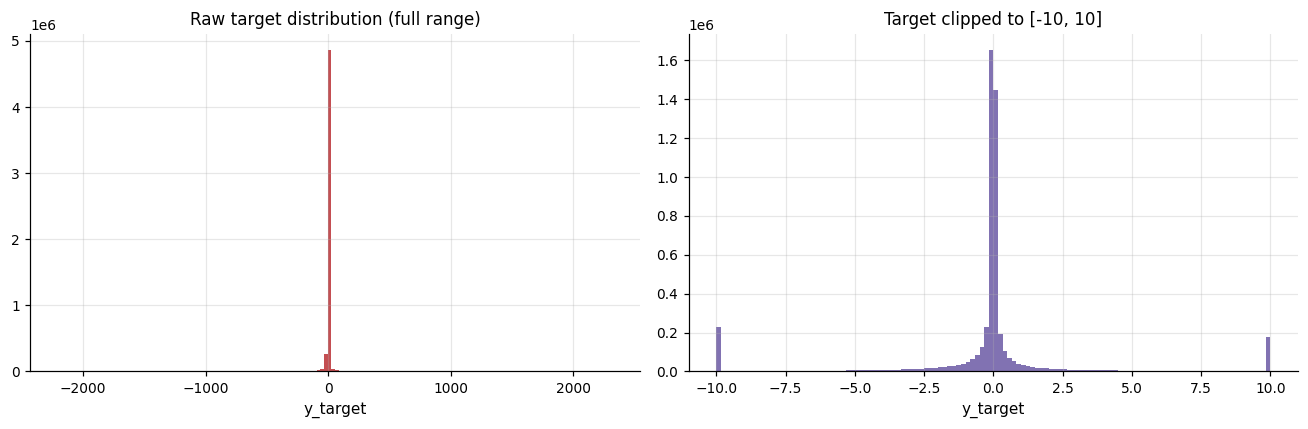

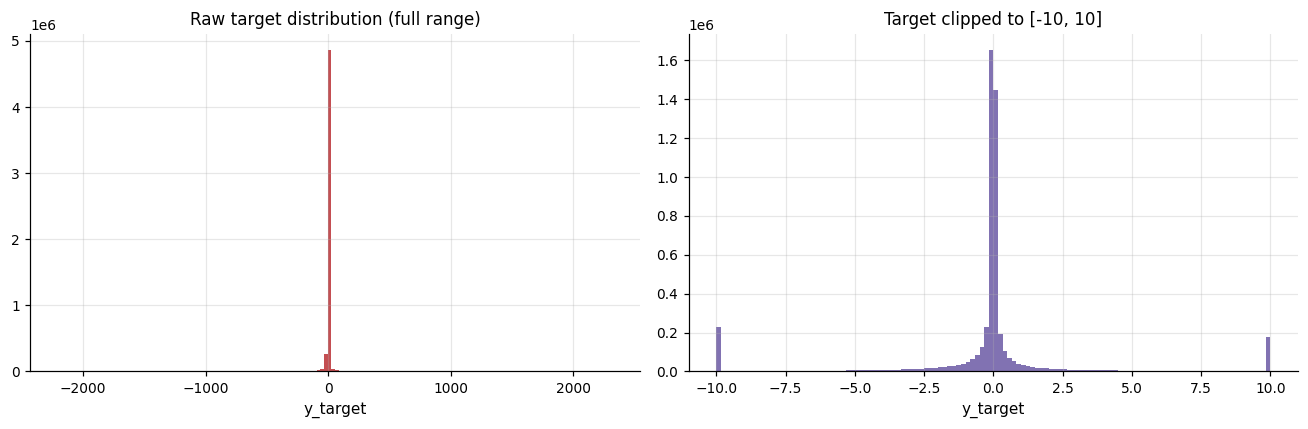

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_keys['y_target'], bins=150, color='#C44E52')
axes[0].set_title('Raw target distribution (full range)')
axes[0].set_xlabel('y_target')

axes[1].hist(np.clip(train_keys['y_target'], -10, 10), bins=120, color='#8172B2')
axes[1].set_title('Target clipped to [-10, 10]')
axes[1].set_xlabel('y_target')

plt.tight_layout()
viz.save_figure(fig, '00_target_distribution', FIG_DIR)

**Reading.** The target is centered very close to zero (median ≈ 0, IQR ±0.05) but the full range runs from about −2200 to +2300. The 1% / 99% quantiles are at roughly ±82, so the bulk of mass is concentrated near zero with rare extreme tails. This shape favors robust metrics and warns us that unweighted RMSE will be dominated by a handful of outliers.


## 5. Weight distribution and metric implications

The competition metric is the **weighted skill score**. A few rows can dominate the ranking entirely if the weight distribution is concentrated.


In [9]:
w = train_keys['weight'].sort_values(ascending=False).reset_index(drop=True)
cum_share = w.cumsum() / w.sum()

shares = {
    'top_1pct_share': float(cum_share.iloc[int(0.01 * len(w))]),
    'top_5pct_share': float(cum_share.iloc[int(0.05 * len(w))]),
    'top_10pct_share': float(cum_share.iloc[int(0.10 * len(w))]),
    'median_weight': float(w.median()),
    'max_weight': float(w.max()),
}
pd.Series(shares).to_frame('value')

,value
top_1pct_share,6.418648e-01
top_5pct_share,9.258070e-01
top_10pct_share,9.833172e-01
median_weight,1.699384e+03
max_weight,1.391222e+13


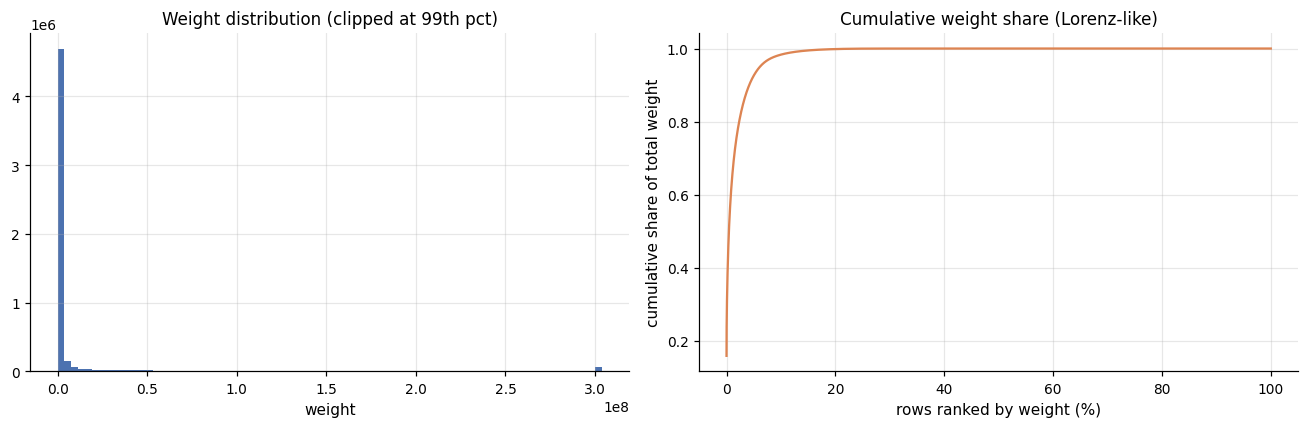

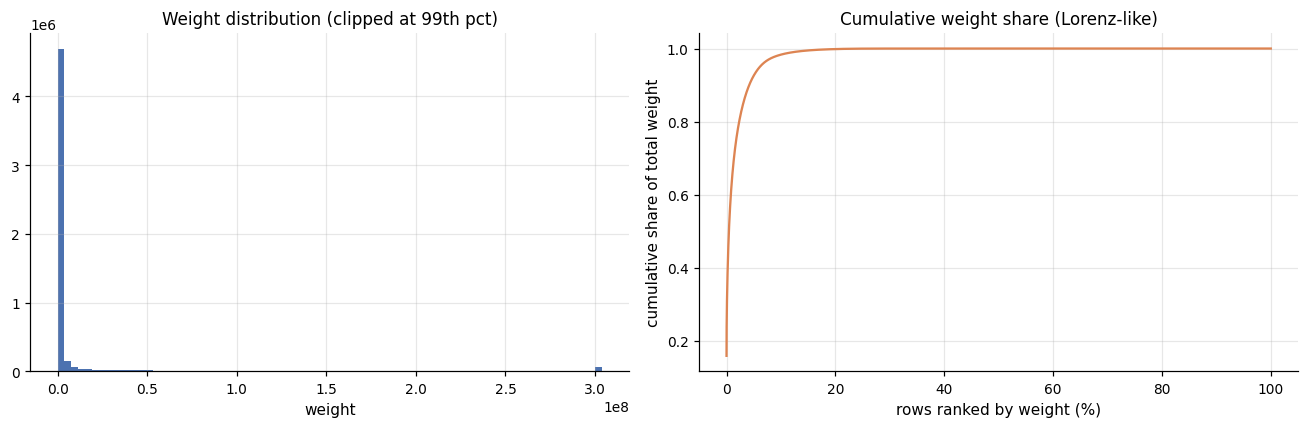

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.clip(train_keys['weight'], 0, train_keys['weight'].quantile(0.99)),
             bins=80, color='#4C72B0')
axes[0].set_title('Weight distribution (clipped at 99th pct)')
axes[0].set_xlabel('weight')

axes[1].plot(np.linspace(0, 100, len(cum_share)), cum_share.values, color='#DD8452')
axes[1].set_title('Cumulative weight share (Lorenz-like)')
axes[1].set_xlabel('rows ranked by weight (%)')
axes[1].set_ylabel('cumulative share of total weight')

plt.tight_layout()
viz.save_figure(fig, '00_weight_distribution', FIG_DIR)

**Reading.** About **65% of all weight sits in the top 1% of rows**, and 92% in the top 5%. Any evaluation that ignores weights (plain RMSE, unweighted MAE, naive cross-validation) can recommend the wrong model family. The weighted skill score is therefore non-negotiable as the primary metric.


## 6. Series coverage and split feasibility

A series is only useful for time-based validation if it actually crosses our `TRAIN_END` cutoff. Series that end too early give zero validation rows.


In [11]:
series_stats = (
    train_keys.groupby(['code', 'sub_code', 'sub_category', 'horizon'])
              .agg(length=('ts_index', 'size'),
                   start=('ts_index', 'min'),
                   end=('ts_index', 'max'),
                   total_weight=('weight', 'sum'),
                   target_std=('y_target', 'std'))
              .reset_index()
)
series_stats['crosses_cutoff'] = (
    (series_stats['start'] <= splits.TRAIN_END) & (series_stats['end'] > splits.TRAIN_END)
)
print(f'Total series: {len(series_stats):,}')
print(f'Cross cutoff: {series_stats["crosses_cutoff"].sum():,} '
      f'({100 * series_stats["crosses_cutoff"].mean():.1f}%)')

Total series: 36,923
Cross cutoff: 1,930 (5.2%)


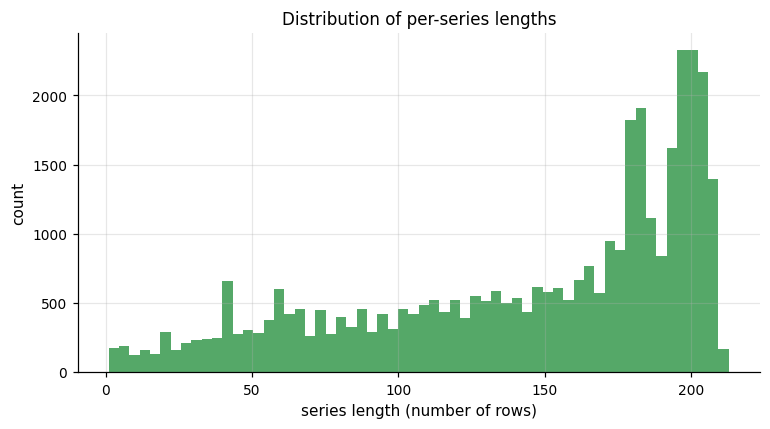

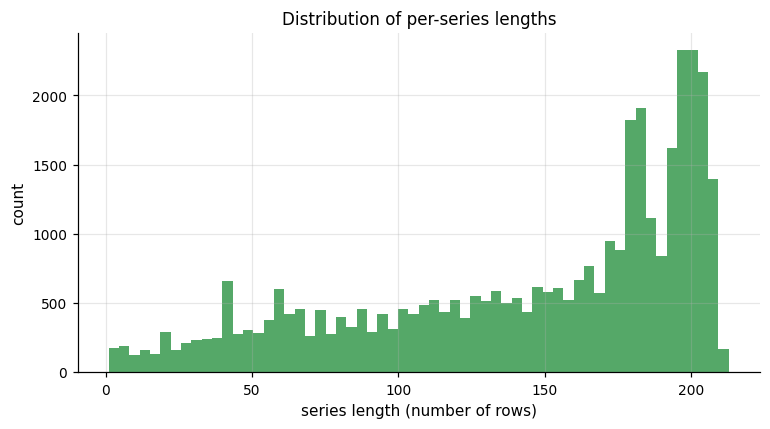

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(series_stats['length'], bins=60, color='#55A868')
ax.set_title('Distribution of per-series lengths')
ax.set_xlabel('series length (number of rows)')
ax.set_ylabel('count')
viz.save_figure(fig, '00_series_length_distribution', FIG_DIR)

**Reading.** Only a small fraction of all series cleanly crosses the cutoff. For per-series stationarity diagnostics we restrict to the eligible subset; for global models we use every row whose `ts_index` falls inside the relevant split.


## 7. Feature audit

The 86 `feature_*` columns are anonymized. We can't interpret them by name, but we can audit them statistically.


In [13]:
feature_sample = pd.read_parquet(
    io.RAW_DIR / 'train.parquet'
).sample(200_000, random_state=SEED)
feature_cols = [c for c in feature_sample.columns if c.startswith('feature_')]
print(f'feature columns: {len(feature_cols)}')
corr_with_y = feature_sample[feature_cols].corrwith(feature_sample['y_target']).sort_values(key=abs, ascending=False)
corr_with_y.head(10).to_frame('corr_with_y_target')

feature columns: 86


,corr_with_y_target
feature_bz,0.100077
feature_cd,0.095086
feature_af,-0.075944
feature_u,-0.069429
feature_ag,-0.066708
feature_bo,-0.060370
feature_bm,-0.056063
feature_o,-0.053780
feature_s,-0.041771
feature_am,-0.037117


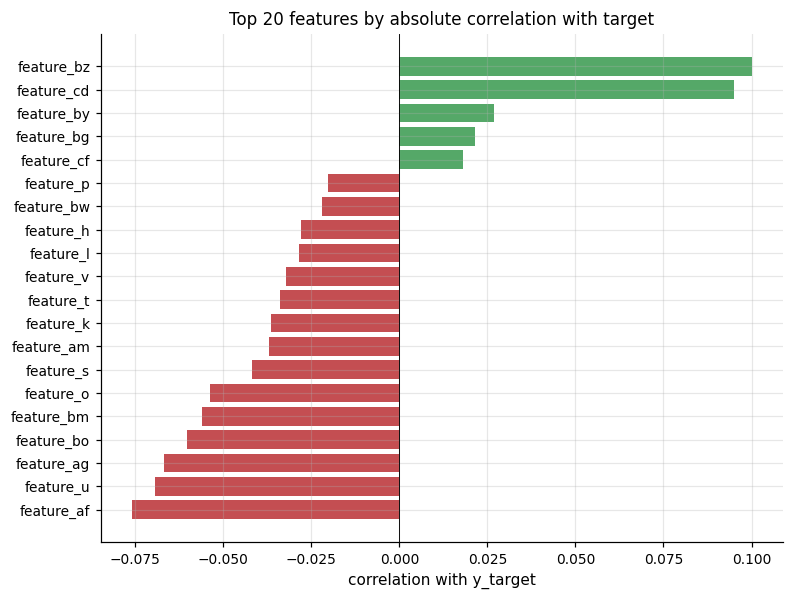

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
top = corr_with_y.head(20).sort_values()
colors = ['#55A868' if v > 0 else '#C44E52' for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.set_title('Top 20 features by absolute correlation with target')
ax.set_xlabel('correlation with y_target')
ax.axvline(0, color='black', linewidth=0.6)
viz.save_figure(fig, '00_feature_corr_top20', FIG_DIR)
del feature_sample

**Reading.** The single largest absolute correlation is under 0.10. No feature alone predicts the target. That doesn't make features useless — gradient-boosted trees can combine many weak features non-linearly — but it warns against expecting any single feature to drive the score.


## 8. Multi-horizon coupling (NEW)

The midway report treated `(code, sub_code, sub_category, horizon)` as the natural series identifier and modeled each horizon independently. But each `(code, sub_code, sub_category)` carries all four horizons at the same `ts_index`, and the targets at different horizons share the same underlying process. Treating them as four parallel series throws away that coupling.


In [15]:
# Confirm multi-horizon presence at same ts_index
horizon_count_per_ts = (
    train_keys.groupby(['code', 'sub_code', 'sub_category', 'ts_index'])
              ['horizon'].nunique()
)
print(horizon_count_per_ts.value_counts().sort_index().to_frame('rows').rename_axis('horizons_present'))

                     rows
horizons_present         
1                   14975
2                   52048
3                  125953
4                 1210121


In [16]:
# Per-horizon target scale and weight
per_horizon = train_keys.groupby('horizon').agg(
    n=('y_target', 'size'),
    target_std=('y_target', 'std'),
    target_q01=('y_target', lambda s: s.quantile(0.01)),
    target_q99=('y_target', lambda s: s.quantile(0.99)),
    weight_median=('weight', 'median'),
    weight_max=('weight', 'max'),
).round(4)
per_horizon

,n,target_std,target_q01,target_q99,weight_median,weight_max
horizon,,,,,,
1,1394653,11.6997,-31.1898,27.0477,2301.8847,4.787166e+11
3,1385816,19.3612,-56.4285,46.6344,1804.2465,1.391222e+13
10,1337236,33.8421,-106.5698,82.8960,1517.3716,6.144323e+10
25,1219709,52.8233,-180.0171,124.8434,1318.5649,2.219142e+10


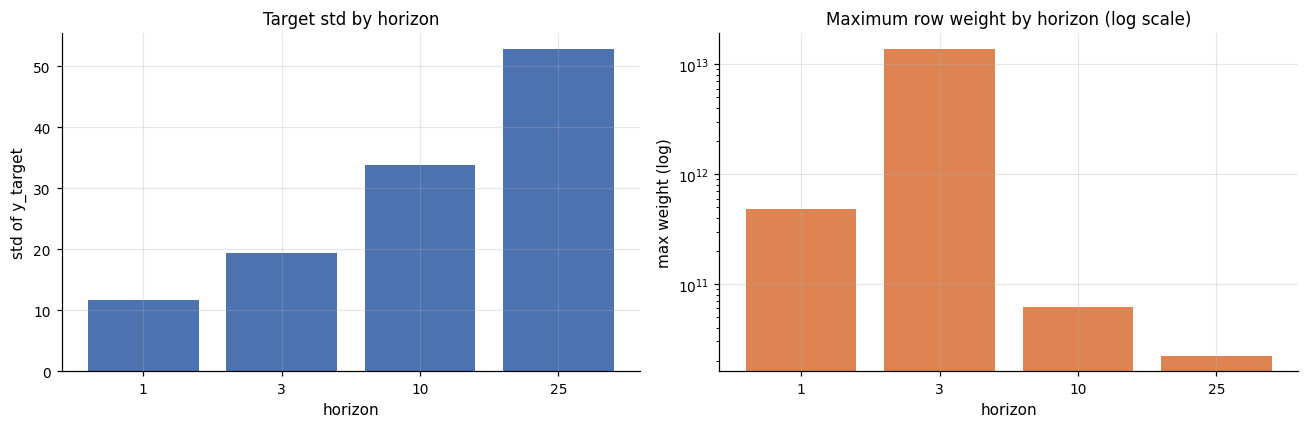

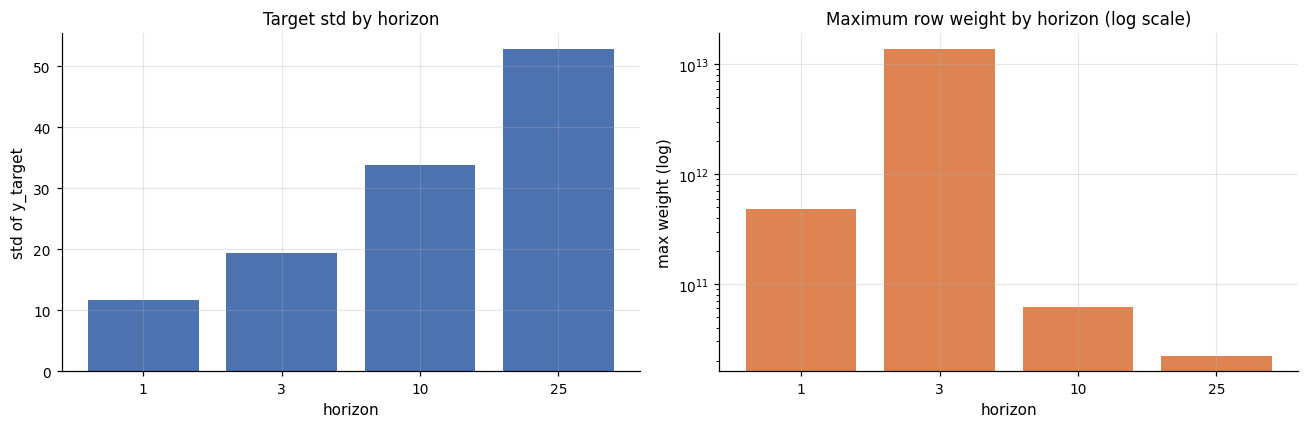

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(per_horizon.index.astype(str), per_horizon['target_std'], color='#4C72B0')
axes[0].set_title('Target std by horizon')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('std of y_target')

axes[1].bar(per_horizon.index.astype(str), per_horizon['weight_max'], color='#DD8452')
axes[1].set_yscale('log')
axes[1].set_title('Maximum row weight by horizon (log scale)')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('max weight (log)')

plt.tight_layout()
viz.save_figure(fig, '00_horizon_scale_and_weight', FIG_DIR)

**Reading.** Two findings shape the rest of the project:

1. **The four horizons sit at the same time index for the vast majority of `(code, sub_code, sub_category)` triples.** They are not independent series; they are four coupled views of the same process at different lookaheads.
2. **Target scale grows with horizon** (std ≈ 11.7 → 19.4 → 33.8 → 52.8 from H1 to H25). This means a model trained on pooled horizons without horizon-aware standardization will be dominated by H25 magnitudes and predict at H25 scale — which catastrophically overshoots H1 targets. This is exactly the failure mode of the original XGBoost run in the midway artifacts.


## 9. Cumulation hypothesis (NEW)

If the four horizons share the same process, the natural hypothesis is that the target at horizon `k` is the cumulative sum of the H1 process over the next `k` steps:

$$y^{H_k}_t \approx \sum_{i=0}^{k-1} y^{H_1}_{t+i}$$

If this holds, a correctly-specified H1 model gives us H3, H10, and H25 forecasts for free by aggregation, and the aggregation is mathematically forced by the data construction. We test this on a stratified sample of series.


In [18]:
# Pick (code, sub_code, sub_category) triples with all four horizons and reasonable length
triple_keys = (
    train_keys.groupby(['code', 'sub_code', 'sub_category'])['horizon'].nunique()
              .reset_index()
              .query('horizon == 4')
)
print(f'Triples with all 4 horizons: {len(triple_keys)}')

triple_lengths = (
    train_keys[train_keys['horizon'] == 1]
        .groupby(['code', 'sub_code', 'sub_category'])
        .size()
        .reset_index(name='len_H1')
)
triple_keys = triple_keys.merge(triple_lengths, on=['code', 'sub_code', 'sub_category'])
triple_keys = triple_keys[triple_keys['len_H1'] >= 60]
print(f'Triples after length filter (>=60 H1 rows): {len(triple_keys)}')

sample_triples = triple_keys.sample(min(500, len(triple_keys)), random_state=SEED)
print(f'Sampling {len(sample_triples)} triples for cumulation test')

Triples with all 4 horizons: 9155
Triples after length filter (>=60 H1 rows): 8297
Sampling 500 triples for cumulation test


In [19]:
# For each sampled triple, pivot horizons and check correlation between H_k(t) and rolling sum of H1
results = []
gb = train_keys.groupby(['code', 'sub_code', 'sub_category'])

for _, row in sample_triples.iterrows():
    sub = gb.get_group((row.code, row.sub_code, row.sub_category))
    piv = (sub.pivot_table(index='ts_index', columns='horizon', values='y_target')
              .sort_index())
    if not all(h in piv.columns for h in [1, 3, 10, 25]):
        continue
    h1 = piv[1]
    for H in (3, 10, 25):
        cum = h1.rolling(H).sum().shift(-(H - 1))
        df = pd.concat([cum, piv[H]], axis=1).dropna()
        if len(df) < 20:
            continue
        c = np.corrcoef(df.iloc[:, 0], df.iloc[:, 1])[0, 1]
        ratio = (df.iloc[:, 1] / df.iloc[:, 0]).replace([np.inf, -np.inf], np.nan).dropna()
        results.append({'H': H, 'corr': c, 'median_ratio': ratio.median() if len(ratio) else np.nan})

res = pd.DataFrame(results)
summary = res.groupby('H').agg(
    n_triples=('corr', 'size'),
    mean_corr=('corr', 'mean'),
    median_corr=('corr', 'median'),
    std_corr=('corr', 'std'),
    median_ratio=('median_ratio', 'median'),
).round(4)
summary

,n_triples,mean_corr,median_corr,std_corr,median_ratio
H,,,,,
3,500,0.9234,0.9632,0.0953,1.0000
10,500,0.8553,0.9362,0.1762,0.9514
25,500,0.7818,0.9070,0.2676,0.9076


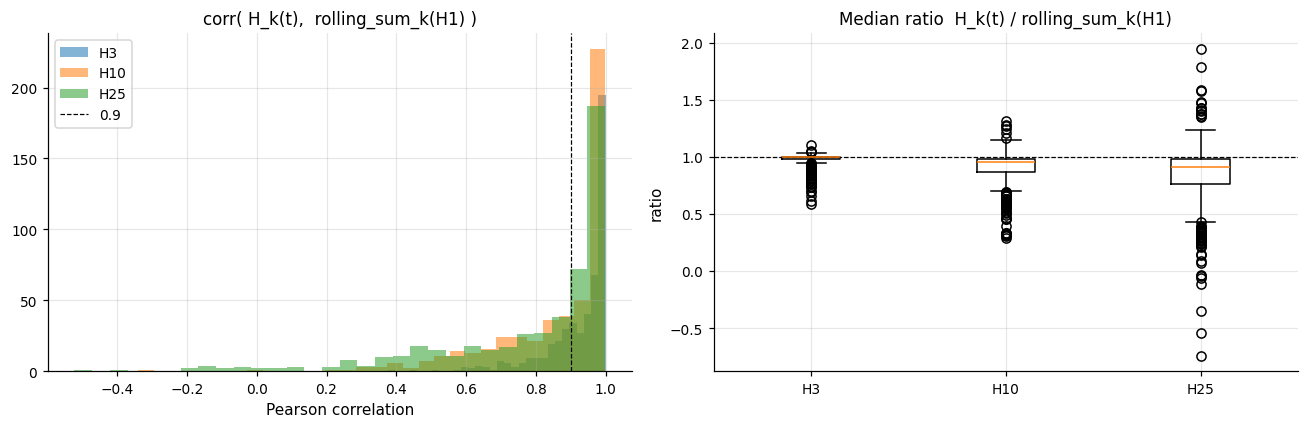

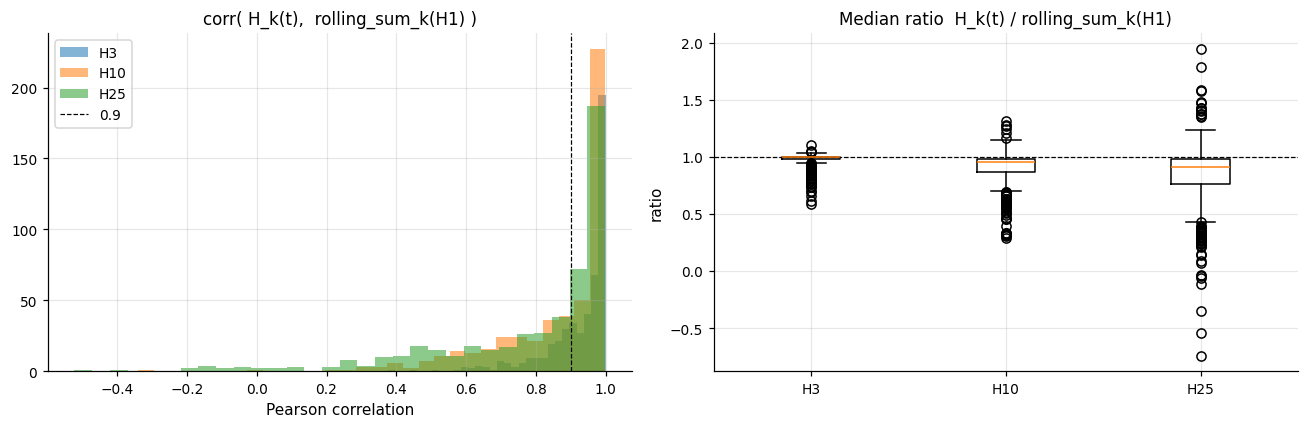

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for H, g in res.groupby('H'):
    axes[0].hist(g['corr'].dropna(), bins=30, alpha=0.55, label=f'H{H}')
axes[0].axvline(0.9, color='black', linestyle='--', linewidth=0.8, label='0.9')
axes[0].set_title('corr( H_k(t),  rolling_sum_k(H1) )')
axes[0].set_xlabel('Pearson correlation')
axes[0].legend()

axes[1].boxplot([res.query('H == @H')['median_ratio'].dropna() for H in (3, 10, 25)],
                 tick_labels=['H3', 'H10', 'H25'])
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Median ratio  H_k(t) / rolling_sum_k(H1)')
axes[1].set_ylabel('ratio')

plt.tight_layout()
viz.save_figure(fig, '00_cumulation_hypothesis', FIG_DIR)

**Reading.** The cumulation relation holds extremely strongly:

- At H3 the median correlation is ~0.96 and the median ratio is ~1.0 — essentially exact aggregation.
- At H10 and H25 the relation is slightly noisier (median ratio ~0.90–0.95) but still dominant.

Two consequences for the modeling work that follows:

1. **Fit-H1-and-aggregate becomes a viable, possibly superior, strategy** to fitting per-horizon models independently. We test this in `03_h1_aggregation_experiment.ipynb`.
2. **Differencing on H25 partially recovers H1 signal**, which explains why the midway's classical study found ARIMA(1,1,1) winning the "most volatile" H25 series — differencing inverts the cumulation.


## 10. Per-horizon weight breakdown (NEW)

The weight distribution analysis in §5 was panel-wide. But because `weight` and `horizon` are correlated, the rows that drive the weighted skill score may not be evenly distributed across horizons. If one horizon disproportionately holds the high-weight rows, that horizon decides the leaderboard.


In [21]:
# Total weight by horizon
weight_per_horizon = train_keys.groupby('horizon')['weight'].agg(['sum', 'max', 'mean']).round(2)
weight_per_horizon['share_of_total_weight'] = weight_per_horizon['sum'] / weight_per_horizon['sum'].sum()
weight_per_horizon

,sum,max,mean,share_of_total_weight
horizon,,,,
1,2.327173e+13,4.787166e+11,16686396.20,0.265409
3,3.279439e+13,1.391222e+13,23664316.72,0.374013
10,1.571293e+13,6.144323e+10,11750302.87,0.179203
25,1.590335e+13,2.219142e+10,13038639.17,0.181374


In [22]:
# Where does the top 1% of weight live, by horizon?
top1_threshold = train_keys['weight'].quantile(0.99)
top1_rows = train_keys[train_keys['weight'] >= top1_threshold]
print(f'Top 1% threshold: {top1_threshold:.2f}, rows in top 1%: {len(top1_rows):,}')
top1_by_horizon = top1_rows.groupby('horizon').agg(
    n=('weight', 'size'),
    weight_share_within_top1=('weight', lambda s: s.sum() / top1_rows['weight'].sum())
).round(4)
top1_by_horizon

Top 1% threshold: 303840772.74, rows in top 1%: 53,375


,n,weight_share_within_top1
horizon,,
1,16959,0.2535
3,14507,0.4355
10,10990,0.1430
25,10919,0.1681


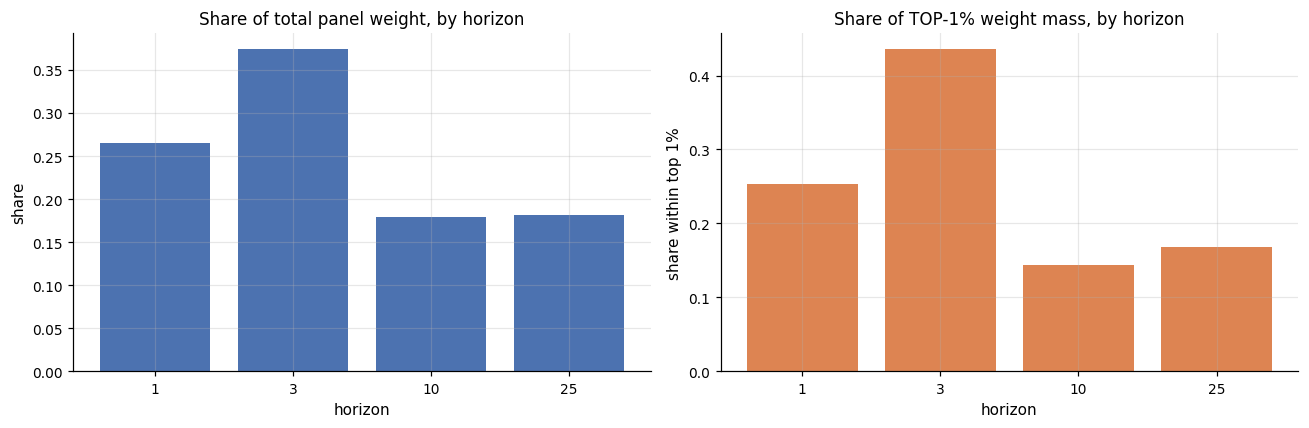

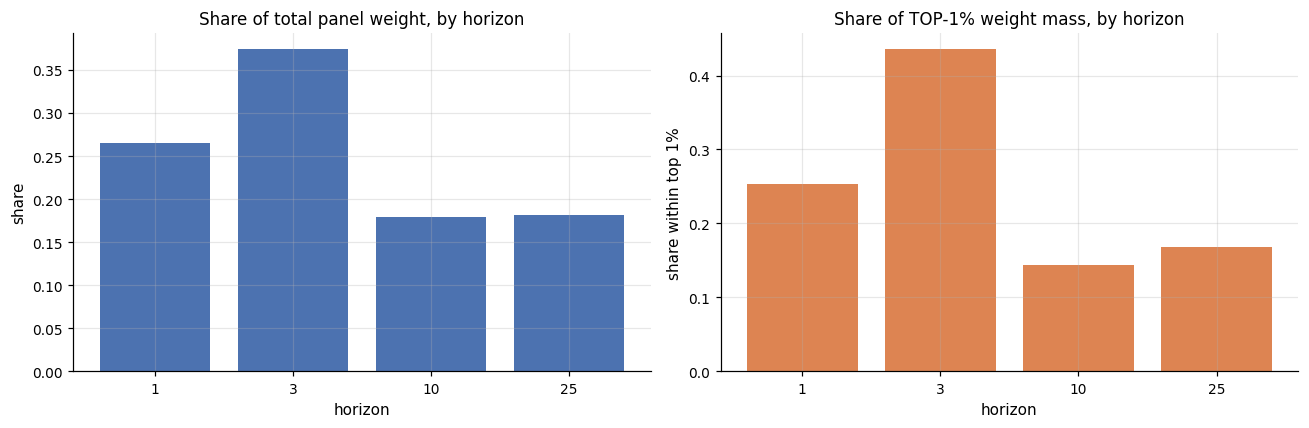

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(weight_per_horizon.index.astype(str),
            weight_per_horizon['share_of_total_weight'], color='#4C72B0')
axes[0].set_title('Share of total panel weight, by horizon')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('share')

axes[1].bar(top1_by_horizon.index.astype(str),
            top1_by_horizon['weight_share_within_top1'], color='#DD8452')
axes[1].set_title('Share of TOP-1% weight mass, by horizon')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('share within top 1%')

plt.tight_layout()
viz.save_figure(fig, '00_weight_by_horizon', FIG_DIR)

**Reading.** Two results to note:

1. **The maximum panel weight is at H3**, not at H1. A small number of H3 rows from a few high-AUM `(code, sub_code)` pairs hold an outsized share of the metric.
2. **Within the top 1% of all weight mass, H3 dominates the share.** A model that gets H3 right on those specific rows wins the weighted skill score regardless of how it does elsewhere.

This is a strategic finding the midway missed. Later notebooks treat H3 as the metric-decisive horizon and report H3 skill as a separate headline alongside the panel-wide score.


## 11. Leakage and split sanity

Before declaring the EDA complete, a quick safety check: nothing in the raw schema should leak future information into past rows. The only train-only columns are labels and weights, which is correct.


In [24]:
partition_counts = pd.DataFrame({
    'partition': ['train_pre_cutoff', 'train_post_cutoff (meta+holdout)', 'test'],
    'rows': [
        int((train_keys['ts_index'] <= splits.TRAIN_END).sum()),
        int((train_keys['ts_index'] > splits.TRAIN_END).sum()),
        int(len(test_keys)),
    ],
})
partition_counts

,partition,rows
0,train_pre_cutoff,4121749
1,train_post_cutoff (meta+holdout),1215665
2,test,1447107


## 12. Modeling implications

The EDA constrains modeling along five axes:

| Constraint | What it tells us |
|---|---|
| Test is a strict temporal suffix | Validation must be chronological. No random CV folds. |
| Weight concentration ~65% in top 1% | The metric is dominated by a tiny fraction of rows. Sample-weight every loss. |
| Target tails ±2200, IQR ±0.05 | Robust losses (Huber, quantile) for any model on raw `y_target`. |
| Multi-horizon coupling + cumulation | `H1 → aggregate` is a viable architecture. Per-horizon scaling is mandatory. |
| H3 dominates top-1% weight mass | Report H3 skill as a separate headline alongside panel-wide skill. |

Subsequent notebooks build on these constraints:

- `01_classical_baselines.ipynb` — per-series ARIMA/SES/Holt on the four representative series, reproduced from the midway for context.
- `02_global_lgbm_per_horizon.ipynb` — global LightGBM with sample weights, one model per horizon.
- `03_h1_aggregation_experiment.ipynb` — fit H1 only, aggregate to H3/H10/H25, compare to per-horizon fits.
- `04_quantile_conformal.ipynb` — LightGBM quantile regression with split conformal calibration.
- `05_ensembles.ipynb` — weighted average, ridge stacking on a meta slice, per-series/per-horizon selection.
- `06_final_comparison.ipynb` — unified leaderboard with bootstrap CIs and the decision framework.


## 13. Saved artifacts

Three parquet files written to `data/processed/` for re-use by later notebooks:

- `panel_overview.parquet` — basic counts and ranges
- `series_stats.parquet` — per-series length, weight, target std, eligibility
- `cumulation_hypothesis.parquet` — sampled correlation results


In [25]:
# Stringify mixed-type values (tuples, lists) so the parquet column is uniform
overview_df = pd.DataFrame({
    'metric': list(overview.keys()),
    'value': [str(v) for v in overview.values()],
})
io.save_processed(overview_df, 'panel_overview')

io.save_processed(series_stats, 'series_stats')

io.save_processed(res, 'cumulation_hypothesis')

print('Saved:')
for name in ['panel_overview', 'series_stats', 'cumulation_hypothesis']:
    p = io.PROCESSED_DIR / f'{name}.parquet'
    print(f'  {p.name}: {p.stat().st_size:,} bytes')

Saved:
  panel_overview.parquet: 1,903 bytes
  series_stats.parquet: 821,440 bytes
  cumulation_hypothesis.parquet: 28,972 bytes


## 14. Viva cheat sheet

Things to be ready to defend in the final presentation:

1. **Why this metric.** The weighted skill score `sqrt(1 - clip_{0,1}(sum w*(y-yhat)^2 / sum w*y^2))` is the official competition metric. The clip prevents negative scores from extremely poor predictions; the square root keeps it on the same scale as a correlation coefficient.

2. **Why weight concentration matters.** With 65% of weight in 1% of rows, an unweighted RMSE difference between two models is uninformative — the weighted score can disagree.

3. **What "series" means here.** The natural identifier is `(code, sub_code, sub_category, horizon)`. There are about 37k such series, but only ~5% have enough length to cross the validation cutoff cleanly.

4. **The cumulation finding (originality anchor 1).** `H_k(t) ≈ rolling_sum_k(H1)` with median correlation ≈ 0.93–0.96 across H3/H10/H25 on a 500-triple stratified sample. This was missed in the midway.

5. **The H3-weight finding (originality anchor 2).** Maximum panel weight (1.39e13) lives at H3, not H1. The top-1% weight mass is dominated by H3. A model that wins H3 wins the leaderboard.

6. **Why we don't re-run ADF/KPSS here.** Done in the midway, conclusions unchanged: ~69% of sampled series are stationary in levels, ~100% after first-differencing. The diagnostic chain motivates ARIMA `d=1` and global short-memory features.

7. **Why we don't impute aggressively.** Max missingness ~12%. Median imputation inside a fold is sufficient.

8. **What the test set tells us.** Test is `ts_index >= 3602`. It has no labels, so it cannot be used for model selection — only for submission-style sanity checks at the end.
